In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip -q install ultralytics opencv-python matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 27.1 MB/s eta 0:00:00


In [3]:
# ============================================================
# 11_pose_exploration.ipynb
#
# Exploración de Human Pose Estimation (HPE) como módulo de
# análisis de intención en el pipeline de detección de armas.
#
# Flujo:
#   1. Detector de armas (Model B) -> frames con arma
#   2. YOLOv8-pose -> keypoints de la persona asociada al arma
#   3. Clasificador geométrico (heurístico) -> AIMING / HOLDING / NEUTRAL
#
# Este notebook es de EXPLORACIÓN:
#   - Visualiza keypoints + esqueleto sobre frames seleccionados
#   - Calcula y muestra la distribución de ángulos clave
#   - Valida la viabilidad del enfoque antes de integrarlo al pipeline
# ============================================================

import os
import shutil
import math
import csv
from pathlib import Path
from collections import defaultdict

import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO

print('✅ Imports OK')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ Imports OK


In [4]:
# ============================================================
# CONFIG
# ============================================================

POS_LIST   = '/content/drive/MyDrive/TFM/datasets/videos/Gun_Action_Recognition_Dataset/splits/handgun_test.txt'
OUT_DIR    = '/content/drive/MyDrive/TFM/experiments/video_tests/GAR/runs/pose_exploration'

WEAPON_DET_WEIGHTS = '/content/drive/MyDrive/TFM/experiments/weapon_det/yolov8m_weapons_B_e50_640/weights/best.pt'
POSE_WEIGHTS       = 'yolov8m-pose.pt'   # se descarga automáticamente de Ultralytics

# Inferencia
IMG_SIZE    = 640
CONF_WEAPON = 0.25
IOU_NMS     = 0.7
CONF_POSE   = 0.5

# Exploración: cuántos clips positivos analizar (None = todos)
MAX_CLIPS       = 10
# Frames a muestrear por clip para visualización/análisis de ángulos
FRAMES_PER_CLIP = 20
# Segundos máximos de cada clip a procesar
MAX_SECONDS     = 15

# Umbral heurístico: ángulo hombro-codo-muñeca >= AIMING_ANGLE_THR -> AIMING
AIMING_ANGLE_THR = 160   # grados (brazo casi recto)
# Confianza mínima de keypoint para usarlo en el cálculo
KP_CONF_THR = 0.3

Path(OUT_DIR).mkdir(parents=True, exist_ok=True)
print('✅ Config OK')

✅ Config OK


In [5]:
# ============================================================
# KEYPOINTS COCO (17 puntos)
# ============================================================
#  0: nose        1: left_eye     2: right_eye
#  3: left_ear    4: right_ear    5: left_shoulder
#  6: right_shoulder  7: left_elbow  8: right_elbow
#  9: left_wrist  10: right_wrist  11: left_hip
# 12: right_hip   13: left_knee   14: right_knee
# 15: left_ankle  16: right_ankle

L_SHOULDER, R_SHOULDER = 5, 6
L_ELBOW,    R_ELBOW    = 7, 8
L_WRIST,    R_WRIST    = 9, 10

SKELETON = [
    (0,1),(0,2),(1,3),(2,4),
    (5,6),
    (5,7),(7,9),
    (6,8),(8,10),
    (5,11),(6,12),(11,12),
    (11,13),(13,15),
    (12,14),(14,16),
]

SKEL_COLOR_MAP = {
    (0,1):(255,200,0),(0,2):(255,200,0),(1,3):(255,200,0),(2,4):(255,200,0),
    (5,6):(0,255,100),
    (5,7):(0,200,255),(7,9):(0,200,255),
    (6,8):(0,200,255),(8,10):(0,200,255),
    (5,11):(0,255,100),(6,12):(0,255,100),(11,12):(0,255,100),
    (11,13):(200,0,255),(13,15):(200,0,255),
    (12,14):(200,0,255),(14,16):(200,0,255),
}

POSE_COLORS = {
    'AIMING':  (0,   0,   255),
    'HOLDING': (0,   165, 255),
    'NEUTRAL': (0,   255, 0  ),
}

print('✅ Keypoint config OK')

✅ Keypoint config OK


In [6]:
# ============================================================
# HELPERS GEOMÉTRICOS Y DE VISUALIZACIÓN
# ============================================================

def angle_between(a, b, c):
    """Ángulo en B formado por BA y BC. Retorna grados [0,180] o None."""
    ba = (a[0]-b[0], a[1]-b[1])
    bc = (c[0]-b[0], c[1]-b[1])
    dot  = ba[0]*bc[0] + ba[1]*bc[1]
    norm = math.sqrt(ba[0]**2+ba[1]**2) * math.sqrt(bc[0]**2+bc[1]**2)
    if norm < 1e-6:
        return None
    return math.degrees(math.acos(max(-1.0, min(1.0, dot/norm))))


def get_arm_angles(kps, confs):
    """Ángulo hombro-codo-muñeca para cada brazo. Retorna dict left/right."""
    results = {'left': None, 'right': None}
    for side, (sh, el, wr) in [('left', (L_SHOULDER, L_ELBOW, L_WRIST)),
                                 ('right',(R_SHOULDER, R_ELBOW, R_WRIST))]:
        if all(confs[i] >= KP_CONF_THR for i in [sh, el, wr]):
            results[side] = angle_between(tuple(kps[sh]), tuple(kps[el]), tuple(kps[wr]))
    return results


def classify_pose(arm_angles):
    """AIMING si algun brazo >= umbral, HOLDING si hay kps, NEUTRAL si no."""
    valid = {k: v for k, v in arm_angles.items() if v is not None}
    if not valid:
        return 'NEUTRAL'
    if any(v >= AIMING_ANGLE_THR for v in valid.values()):
        return 'AIMING'
    return 'HOLDING'


def bbox_center(box):
    return ((box[0]+box[2])/2, (box[1]+box[3])/2)


def find_nearest_person(weapon_box, person_boxes):
    if not person_boxes:
        return None
    wc = bbox_center(weapon_box)
    return int(np.argmin([math.dist(wc, bbox_center(pb)) for pb in person_boxes]))


def draw_skeleton(frame, kps, confs):
    for (i, j) in SKELETON:
        if confs[i] >= KP_CONF_THR and confs[j] >= KP_CONF_THR:
            pt1 = (int(kps[i][0]), int(kps[i][1]))
            pt2 = (int(kps[j][0]), int(kps[j][1]))
            cv2.line(frame, pt1, pt2, SKEL_COLOR_MAP.get((i,j),(200,200,200)), 2)
    for idx, (x, y) in enumerate(kps):
        if confs[idx] >= KP_CONF_THR:
            r = 5 if idx in [L_WRIST, R_WRIST] else 3
            cv2.circle(frame, (int(x), int(y)), r, (255,255,255), -1)


def annotate_frame(frame, weapon_boxes, person_kps_list, pose_labels, arm_angles_list):
    vis = frame.copy()
    for (x1,y1,x2,y2,conf) in weapon_boxes:
        cv2.rectangle(vis,(int(x1),int(y1)),(int(x2),int(y2)),(0,255,255),2)
        cv2.putText(vis,f'weapon {conf:.2f}',(int(x1),int(y1)-8),
                    cv2.FONT_HERSHEY_SIMPLEX,0.5,(0,255,255),1)
    for idx,(kps,confs_kp) in enumerate(person_kps_list):
        label  = pose_labels[idx] if idx < len(pose_labels) else 'NEUTRAL'
        angles = arm_angles_list[idx] if idx < len(arm_angles_list) else {}
        color  = POSE_COLORS.get(label,(200,200,200))
        draw_skeleton(vis, kps, confs_kp)
        hx, hy = int(kps[0][0]), max(0, int(kps[0][1])-15)
        cv2.putText(vis, label, (hx,hy), cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)
        atxt = ''
        if angles.get('left')  is not None: atxt += f"L:{angles['left']:.0f}deg "
        if angles.get('right') is not None: atxt += f"R:{angles['right']:.0f}deg"
        if atxt:
            cv2.putText(vis, atxt.strip(), (hx, hy+20),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.45, color, 1)
    return vis


print('✅ Helpers OK')

✅ Helpers OK


In [7]:
weapon_model = YOLO(WEAPON_DET_WEIGHTS)
pose_model   = YOLO(POSE_WEIGHTS)
print('✅ Modelos cargados')

✅ Modelos cargados


In [8]:
# ============================================================
# BLOQUE A — Exploración visual
# Procesa MAX_CLIPS clips positivos, muestrea frames con arma
# y genera visualización con esqueletos + labels de pose
# ============================================================
print('=' * 60)
print('BLOQUE A — Exploración visual (keypoints + clasificación)')
print('=' * 60)

pos_paths = [Path(l.strip()) for l in Path(POS_LIST).read_text().splitlines() if l.strip()]
if MAX_CLIPS:
    pos_paths = pos_paths[:MAX_CLIPS]

vis_frames    = []   # frames anotados para la grid
angle_records = []   # datos para análisis de distribución

for vp in pos_paths:
    if not vp.exists():
        print(f'  Skipping missing: {vp}')
        continue

    clip_id  = vp.parent.name
    local_in = f'/content/tmp_pose_{clip_id}.mp4'
    shutil.copy2(str(vp), local_in)

    cap      = cv2.VideoCapture(local_in)
    fps      = cap.get(cv2.CAP_PROP_FPS) or 30
    n_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    max_f    = min(n_frames, int(MAX_SECONDS * fps))

    sample_indices = set(np.linspace(0, max_f-1, FRAMES_PER_CLIP, dtype=int).tolist())

    clip_vis = []
    frame_i  = 0

    while frame_i < max_f:
        ok, frame = cap.read()
        if not ok:
            break
        if frame_i not in sample_indices:
            frame_i += 1
            continue

        # --- Detección de armas ---
        wr = weapon_model.predict(frame, imgsz=IMG_SIZE, conf=CONF_WEAPON,
                                   iou=IOU_NMS, verbose=False, device='cuda')[0]
        weapon_boxes = []
        if wr.boxes is not None and len(wr.boxes) > 0:
            for b in wr.boxes:
                x1,y1,x2,y2 = map(float, b.xyxy[0])
                weapon_boxes.append((x1,y1,x2,y2,float(b.conf[0])))

        # Solo analizar pose si hay arma
        if not weapon_boxes:
            frame_i += 1
            continue

        # --- Estimación de pose ---
        pr = pose_model.predict(frame, imgsz=IMG_SIZE, conf=CONF_POSE,
                                 verbose=False, device='cuda')[0]

        person_kps_list  = []
        person_boxes_raw = []
        pose_labels      = []
        arm_angles_list  = []

        if pr.keypoints is not None and len(pr.keypoints) > 0:
            kps_data  = pr.keypoints.xy.cpu().numpy()    # (N,17,2)
            conf_data = pr.keypoints.conf.cpu().numpy()  # (N,17)
            if pr.boxes is not None:
                for b in pr.boxes:
                    person_boxes_raw.append(list(map(float, b.xyxy[0])))
            for p_idx in range(len(kps_data)):
                kps   = kps_data[p_idx]
                confs = conf_data[p_idx]
                angles = get_arm_angles(kps, confs)
                label  = classify_pose(angles)
                person_kps_list.append((kps, confs))
                pose_labels.append(label)
                arm_angles_list.append(angles)
                angle_records.append({
                    'clip':    clip_id,
                    'frame':   frame_i,
                    'person':  p_idx,
                    'label':   label,
                    'angle_L': angles.get('left'),
                    'angle_R': angles.get('right'),
                })

        annotated = annotate_frame(frame, weapon_boxes, person_kps_list,
                                    pose_labels, arm_angles_list)
        cv2.putText(annotated, f'{clip_id}  f{frame_i}',
                    (8,20), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (220,220,220), 1)
        clip_vis.append(annotated)
        frame_i += 1

    cap.release()
    os.remove(local_in)
    vis_frames.extend(clip_vis)
    print(f'  OK {clip_id} — {len(clip_vis)} frames anotados')

print(f'Total frames anotados  : {len(vis_frames)}')
print(f'Total registros angulos: {len(angle_records)}')

BLOQUE A — Exploración visual (keypoints + clasificación)
  OK PAH1_C1_P1_V1_HB_3 — 4 frames anotados
  OK PAH1_C1_P1_V1_HB_4 — 10 frames anotados
  OK PAH1_C1_P2_V1_HB_1 — 10 frames anotados
  OK PAH1_C1_P2_V1_HB_3 — 11 frames anotados
  OK PAH1_C1_P4_V1_HB_1 — 10 frames anotados
  OK PAH1_C1_P4_V1_HB_2 — 8 frames anotados
  OK PAH1_C2_P3_V1_HB_1 — 4 frames anotados
  OK PAH1_C2_P3_V1_HB_3 — 2 frames anotados
  OK PAH1_C2_P3_V2_HB_2 — 4 frames anotados
  OK PAH1_C2_P3_V2_HB_3 — 5 frames anotados
Total frames anotados  : 68
Total registros angulos: 65


In [9]:
def show_frame_grid(frames, cols=4, target_w=320, title=''):
    if not frames:
        print('Sin frames para mostrar.')
        return
    rows = math.ceil(len(frames) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(cols*4, rows*3))
    if title:
        fig.suptitle(title, fontsize=13, fontweight='bold')
    axes_flat = axes.flatten() if hasattr(axes, 'flatten') else [axes]
    for i, ax in enumerate(axes_flat):
        if i < len(frames):
            f = frames[i]
            h, w = f.shape[:2]
            resized = cv2.resize(f, (target_w, int(h * target_w / w)))
            ax.imshow(cv2.cvtColor(resized, cv2.COLOR_BGR2RGB))
        ax.axis('off')
    plt.tight_layout()
    plt.show()

show_frame_grid(vis_frames[:20], cols=4, title='Exploración HPE — Clips positivos GAR')

Output hidden; open in https://colab.research.google.com to view.

BLOQUE B — Distribución de ángulos hombro-codo-muñeca
  Angulos validos totales : 122
  Frames AIMING   : 31
  Frames HOLDING  : 31
  Frames NEUTRAL  : 3
  Media   : 148.5 deg
  Mediana : 150.1 deg
  Std     : 19.3 deg
  Min     : 73.9 deg
  Max     : 179.9 deg
  % >= 160 deg (AIMING): 31.1%
Histograma guardado en: /content/drive/MyDrive/TFM/experiments/video_tests/GAR/runs/pose_exploration/angle_distribution.png


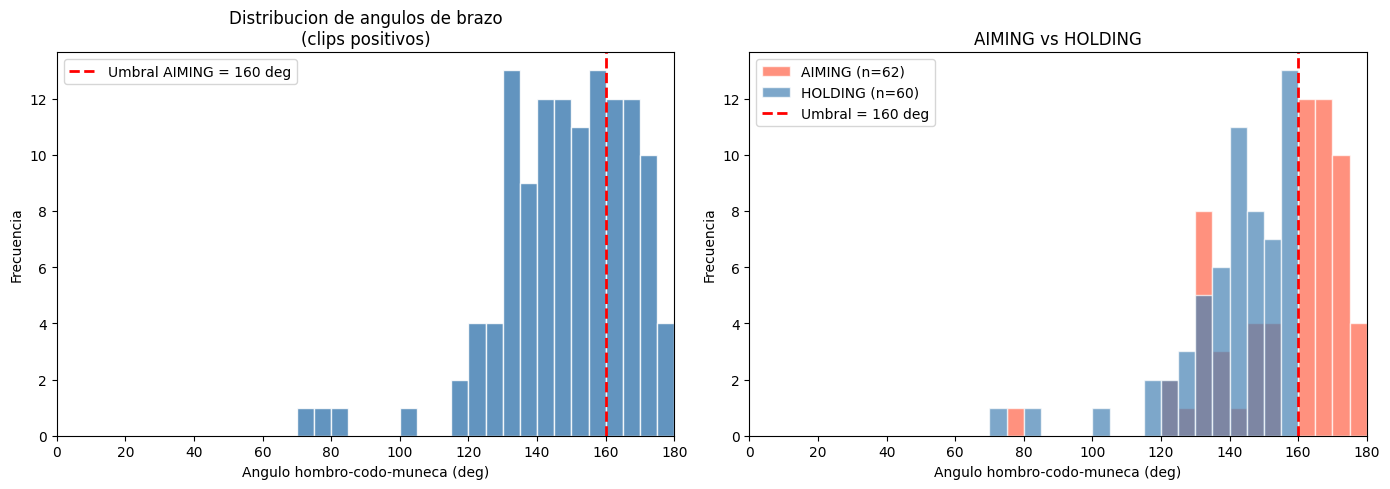

In [10]:
# ============================================================
# BLOQUE B — Distribución de ángulos hombro-codo-muñeca
# ============================================================
print('=' * 60)
print('BLOQUE B — Distribución de ángulos hombro-codo-muñeca')
print('=' * 60)

angles_all    = []
angles_aiming  = []
angles_holding = []

for rec in angle_records:
    for side in ['angle_L', 'angle_R']:
        a = rec[side]
        if a is not None:
            angles_all.append(a)
            if rec['label'] == 'AIMING':
                angles_aiming.append(a)
            else:
                angles_holding.append(a)

n_aiming  = sum(1 for r in angle_records if r['label'] == 'AIMING')
n_holding = sum(1 for r in angle_records if r['label'] == 'HOLDING')
n_neutral = sum(1 for r in angle_records if r['label'] == 'NEUTRAL')

print(f'  Angulos validos totales : {len(angles_all)}')
print(f'  Frames AIMING   : {n_aiming}')
print(f'  Frames HOLDING  : {n_holding}')
print(f'  Frames NEUTRAL  : {n_neutral}')

if angles_all:
    print(f'  Media   : {np.mean(angles_all):.1f} deg')
    print(f'  Mediana : {np.median(angles_all):.1f} deg')
    print(f'  Std     : {np.std(angles_all):.1f} deg')
    print(f'  Min     : {np.min(angles_all):.1f} deg')
    print(f'  Max     : {np.max(angles_all):.1f} deg')
    pct = sum(a >= AIMING_ANGLE_THR for a in angles_all) / len(angles_all) * 100
    print(f'  % >= {AIMING_ANGLE_THR} deg (AIMING): {pct:.1f}%')

# --- Histogramas ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
if angles_all:
    ax.hist(angles_all, bins=36, range=(0,180), color='steelblue',
            edgecolor='white', alpha=0.85)
    ax.axvline(AIMING_ANGLE_THR, color='red', linestyle='--', linewidth=2,
               label=f'Umbral AIMING = {AIMING_ANGLE_THR} deg')
    ax.set_xlabel('Angulo hombro-codo-muneca (deg)')
    ax.set_ylabel('Frecuencia')
    ax.set_title('Distribucion de angulos de brazo\n(clips positivos)')
    ax.legend()
    ax.set_xlim(0, 180)

ax2 = axes[1]
if angles_aiming:
    ax2.hist(angles_aiming, bins=36, range=(0,180),
             color='tomato', alpha=0.7, label=f'AIMING (n={len(angles_aiming)})',
             edgecolor='white')
if angles_holding:
    ax2.hist(angles_holding, bins=36, range=(0,180),
             color='steelblue', alpha=0.7, label=f'HOLDING (n={len(angles_holding)})',
             edgecolor='white')
ax2.axvline(AIMING_ANGLE_THR, color='red', linestyle='--', linewidth=2,
            label=f'Umbral = {AIMING_ANGLE_THR} deg')
ax2.set_xlabel('Angulo hombro-codo-muneca (deg)')
ax2.set_ylabel('Frecuencia')
ax2.set_title('AIMING vs HOLDING')
ax2.legend()
ax2.set_xlim(0, 180)

plt.tight_layout()
hist_path = Path(OUT_DIR) / 'angle_distribution.png'
plt.savefig(str(hist_path), dpi=150, bbox_inches='tight')
print(f'Histograma guardado en: {hist_path}')
plt.show()

In [11]:
# ============================================================
# BLOQUE C — Distribución de poses por clip
# ============================================================
print('=' * 60)
print('BLOQUE C — Distribucion de poses por clip')
print('=' * 60)

clip_label_counts = defaultdict(lambda: defaultdict(int))
for rec in angle_records:
    clip_label_counts[rec['clip']][rec['label']] += 1

print(f"{'Clip':<35} {'AIMING':>8} {'HOLDING':>8} {'NEUTRAL':>8}  Dominante")
print('-' * 72)
for clip_id in sorted(clip_label_counts):
    counts = clip_label_counts[clip_id]
    a = counts.get('AIMING', 0)
    h = counts.get('HOLDING', 0)
    n = counts.get('NEUTRAL', 0)
    dominant = max(counts, key=counts.get)
    print(f'{clip_id:<35} {a:>8} {h:>8} {n:>8}  {dominant}')

BLOQUE C — Distribucion de poses por clip
Clip                                  AIMING  HOLDING  NEUTRAL  Dominante
------------------------------------------------------------------------
PAH1_C1_P1_V1_HB_3                         4        0        0  AIMING
PAH1_C1_P1_V1_HB_4                         1        8        1  HOLDING
PAH1_C1_P2_V1_HB_1                         3        6        0  HOLDING
PAH1_C1_P2_V1_HB_3                        10        0        0  AIMING
PAH1_C1_P4_V1_HB_1                         7        2        1  AIMING
PAH1_C1_P4_V1_HB_2                         1        7        0  HOLDING
PAH1_C2_P3_V1_HB_1                         2        1        0  AIMING
PAH1_C2_P3_V1_HB_3                         0        2        0  HOLDING
PAH1_C2_P3_V2_HB_2                         2        1        1  AIMING
PAH1_C2_P3_V2_HB_3                         1        4        0  HOLDING


In [12]:
# ============================================================
# BLOQUE D — Guardar frames anotados y CSV de ángulos
# ============================================================
print('=' * 60)
print('BLOQUE D — Guardando outputs')
print('=' * 60)

frames_out_dir = Path(OUT_DIR) / 'annotated_frames'
frames_out_dir.mkdir(parents=True, exist_ok=True)
for i, frame in enumerate(vis_frames):
    cv2.imwrite(str(frames_out_dir / f'frame_{i:04d}.jpg'), frame)
print(f'  {len(vis_frames)} frames guardados en: {frames_out_dir}')

if angle_records:
    csv_path = Path(OUT_DIR) / 'angle_records.csv'
    with open(csv_path, 'w', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=angle_records[0].keys())
        writer.writeheader()
        writer.writerows(angle_records)
    print(f'  Registros de angulos guardados en: {csv_path}')

print('Exploracion completa.')

BLOQUE D — Guardando outputs
  68 frames guardados en: /content/drive/MyDrive/TFM/experiments/video_tests/GAR/runs/pose_exploration/annotated_frames
  Registros de angulos guardados en: /content/drive/MyDrive/TFM/experiments/video_tests/GAR/runs/pose_exploration/angle_records.csv
Exploracion completa.
